<a href="https://colab.research.google.com/github/Sidp2709/Lost_revenue_data_analysis_project/blob/main/ColabProject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hello! In this project im going to analyse a public dataset from Asos with the purpose of providing insights and reccomendations according to the results of my data analysis. I hope you find this project as interesting as it was for me when I decided to take it on!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the dataset and skipping lines that may be impartial
df = pd.read_csv('/content/products_asos.csv', on_bad_lines='skip')

#I will be using the price columns quite a lot in this project so I will "force" the price column to be a number in order to avoid any potential errors in my code later on
df['price']= pd.to_numeric(df['price'], errors='coerce')
# In case there is no number I will drop the whole row from the table
df.dropna(subset=['price'])

print(f'Data Loaded: {len(df)} rows')
df.head()

Data Loaded: 30845 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30845 entries, 0 to 30844
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          30827 non-null  object 
 1   name         30827 non-null  object 
 2   size         30827 non-null  object 
 3   category     30827 non-null  object 
 4   price        18378 non-null  float64
 5   color        30827 non-null  object 
 6   sku          30827 non-null  float64
 7   description  30827 non-null  object 
 8   images       30827 non-null  object 
dtypes: float64(2), object(7)
memory usage: 2.1+ MB


In [ ]:
df.describe(include='all')

,url,name,size,category,price,color,sku,description,images
count,30827,30827,30827,30827,18378.000000,30827,3.082700e+04,30827,30827
unique,30468,29493,5073,29492,NaN,3636,NaN,29971,29972
top,https://www.asos.com/in-the-style/in-the-style...,ASOS 4505 icon performance t-shirt,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14,UK 16,UK 18",ASOS 4505 icon performance t-shirt,NaN,BLACK,NaN,[{'Product Details': 'Coats & Jackets by Collu...,['https://images.asos-media.com/products/collu...
freq,2,7,2912,7,NaN,3289,NaN,5,5
mean,NaN,NaN,NaN,NaN,47.206741,NaN,1.154976e+08,NaN,NaN
std,NaN,NaN,NaN,NaN,35.973351,NaN,2.259336e+07,NaN,NaN
min,NaN,NaN,NaN,NaN,4.500000,NaN,4.010200e+05,NaN,NaN
25%,NaN,NaN,NaN,NaN,26.000000,NaN,1.173468e+08,NaN,NaN
50%,NaN,NaN,NaN,NaN,36.000000,NaN,1.199234e+08,NaN,NaN
75%,NaN,NaN,NaN,NaN,56.000000,NaN,1.228726e+08,NaN,NaN


In [ ]:
df.isnull().sum()

,0
url,18
name,18
size,18
category,18
price,12467
color,18
sku,18
description,18
images,18


I'm looking at this data as an outsider and I'm looking for any mistakes or missed opportunitties. I'm looking to find how much money, if any, they company is losing because their best selling products are not in stock. To achieve this, I will be linking specific products to their brands using the description column.

In [ ]:
# I need to make sure the description column is a string so my code runs okay.

df['description'] = df['description'].astype(str)

# To gorup the products by brand I will be text splitting and only getting the words that come after "by" in the description column since that's where the brand is most commonly referenced in this dataset.
# My method may not be the best generally but in this particular project I believe it is a viable option.

def get_brand(text):
  if 'by' in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "Unknown"
    return "Unknown"

df['brand_raw'] = df['description'].apply(get_brand)

df.head(5)

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket


Since the above code returns only one word I can create a map that the code can follow in order to show the brand names correctly. Also, I'm going to drop any null values throughout the dataset so they dont cause any problems in my revenue calculations.

In [ ]:
brand_map = {

           'New': 'New Look',
           'River' : 'River Island',
           'Miss': 'Miss Selfridge',
           'TopshopWelcome': 'Topshop'

}

df['Brand'] =  df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

#I want to locate the top 5 brands that have the most sales and therefore are important contributions to the income of Asos.

brand_count= df['Brand'].value_counts()
valid_brands = brand_count[brand_count >5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()

print(f"Original df_clean size: {len(df_clean)} rows")

# Drop rows where 'price' is null, as these are critical for revenue calculations
df_clean.dropna(subset=['price'], inplace=True)

# Drop any remaining rows with null values in other columns
df_clean.dropna(inplace=True)

print(f"df_clean size after dropping nulls: {len(df_clean)} rows")

df_clean.isnull().sum()

print(df_clean['Brand'].value_counts().head(5))


Original df_clean size: 27795 rows
df_clean size after dropping nulls: 16395 rows
Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


Now I want to locate the items that are out of stock. If there are stockouts, then there may be an opportunity to increase revenue by purchasing more stock for those items in the future.

In [ ]:
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str, str):
    return 0, 0.0

  #Splitting "UK 6, UK 8 - Out of stock" into a list.
  sizes = size_str.split(',')
  total_sizes = len(sizes)

  #Counting how many times the items are out of stock.
  out_of_stock_count = size_str.count('Out of stock')

  #Calculatining the rate (0.0 to 1.0)
  rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

  return out_of_stock_count, rate

metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))

df_clean['Stockout_Count'] = [x[0] for x in metrics]
df_clean['Stockout_Rate'] = [x[1] for x in metrics]

#Now I need to see the revenue lost due to these items that are out of stock.

df_clean['Lost-Revenue'] = df_clean['price'] * df_clean['Stockout_Count']

cols = ['Brand', 'name', 'price', 'Stockout_Count','Stockout_Rate', 'Lost-Revenue']
print(df_clean.sort_values(by='Lost-Revenue', ascending=False).head(5)[cols])

                  Brand                                               name  \
2941            Barbour               Barbour Beadnell wax jacket in black   
2679   BarbourExclusive  Barbour x ASOS exclusive Stephanie wax parka i...   
21948           Topshop  Topshop premium real leather collared zip thro...   
2715               ASOS  ASOS DESIGN premium real leather trench coat i...   
15584              ASOS  ASOS EDITION geo embellished fringe plunge mid...   

       price  Stockout_Count  Stockout_Rate  Lost-Revenue  
2941   219.0               9          0.900        1971.0  
2679   279.0               7          0.875        1953.0  
21948  260.0               7          0.875        1820.0  
2715   220.0               7          0.875        1540.0  
15584  250.0               6          0.750        1500.0  


Now I want to visualize my results so its easier to understand the changes that have to be made.

Total Lost Revenue: $1,086,505.53


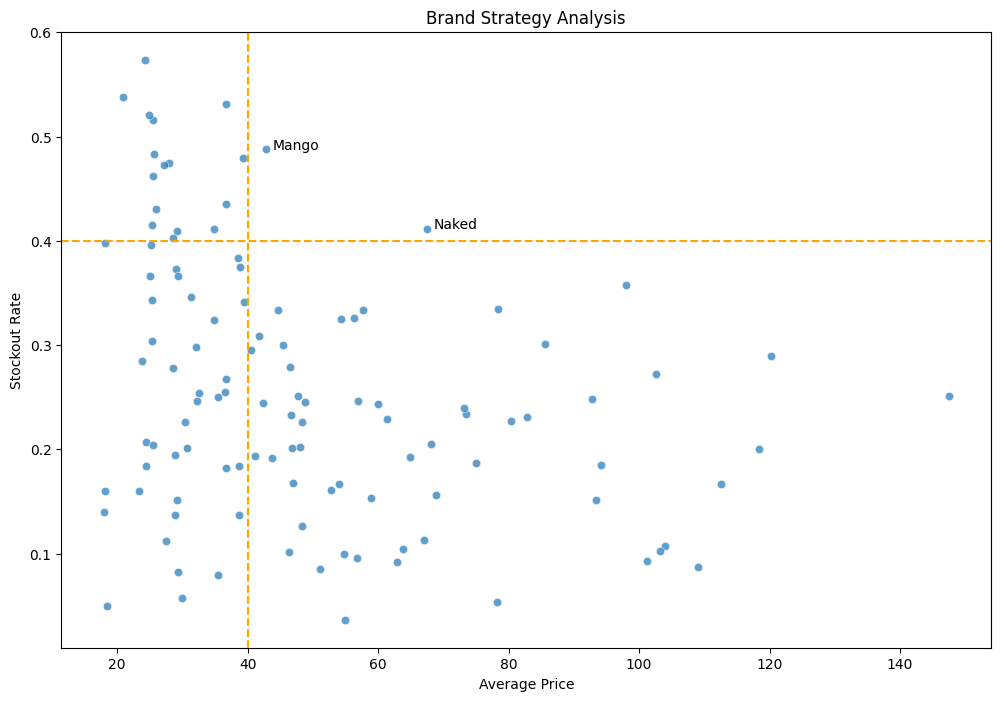

In [ ]:
brand_strategy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Rate': 'mean',
    'Lost-Revenue': 'sum',
    'name': 'count'
}).reset_index()

#Filtering brands by relevance
brand_strategy = brand_strategy[brand_strategy['name'] > 15]

total_lost_revenue = brand_strategy['Lost-Revenue'].sum()
print(f"Total Lost Revenue: ${total_lost_revenue:,.2f}")


plt.figure(figsize=(12,8))
sns.scatterplot(
    data=brand_strategy,
    x='price',
    y='Stockout_Rate',
    sizes=[50 , 500],
    alpha=0.7
)

winners = brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout_Rate'] > 0.4)
]


for i in range(len(winners)):
  plt.text(
      winners.iloc[i]['price']+1,
      winners.iloc[i]['Stockout_Rate'],
      winners.iloc[i]['Brand']
  )

plt.title('Brand Strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='Orange', linestyle='--')
plt.axhline(y=0.4, color='Orange', linestyle='--')
plt.show()

From the chart, Im noticing that most inventory has items that have low price and low demand since they are not out of sotck as often. However, in the upper right qudrant im noticing some brands that are seeing higher demamd in the >40$ price point, meaning most customers are willing to pay a price premium for their products.



# **Suggested Strategy**

---
While lost revenue can never be reduced to zero, we can minimize it significantly through targeted strategic decisions. In this case, I recommend prioritizing the products in the top-right quadrant, which combine higher prices with strong demand. I also suggest increasing focus on the top-left quadrant, where products deliver high demand at lower price points. For the bottom-left and bottom-right quadrants, however, we should consider reducing emphasis on these items, as they appear to be inflating costs with minimal contribution to revenue.
